<a href="https://colab.research.google.com/github/guru-ppriyan/ml_intern_cognifyz/blob/main/Cuisine_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
import pandas as pd

df = pd.read_csv("/content/Dataset  (1).csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Duplicate rows: 0


In [10]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown").astype(str)

df["Primary Cuisine"] = (
    df["Cuisines"]
    .str.split(",")
    .str[0]
    .str.strip()
)

print("Number of unique primary cuisines:",
      df["Primary Cuisine"].nunique())

print("\nTop cuisines:")
print(df["Primary Cuisine"].value_counts().head(15))

Number of unique primary cuisines: 120

Top cuisines:
Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64


In [11]:

top_cuisines = df["Primary Cuisine"].value_counts().head(10).index

classification_df = df[
    df["Primary Cuisine"].isin(top_cuisines)
].copy()

print("Classification dataset shape:", classification_df.shape)
print("\nCuisine distribution:")
print(classification_df["Primary Cuisine"].value_counts())

Classification dataset shape: (7014, 22)

Cuisine distribution:
Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Name: count, dtype: int64


In [12]:
X = classification_df[
    [
        "Average Cost for two",
        "Price range",
        "Votes",
        "Has Table booking",
        "Has Online delivery",
        "City",
        "Aggregate rating"
    ]
]

y = classification_df["Primary Cuisine"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7014, 7)
Target shape: (7014,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5611, 7)
Testing set: (1403, 7)


In [14]:
categorical_features = [
    "Has Table booking",
    "Has Online delivery",
    "City"
]

numeric_features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Aggregate rating"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ],
    remainder="passthrough"
)

print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)

Categorical features: ['Has Table booking', 'Has Online delivery', 'City']
Numerical features: ['Average Cost for two', 'Price range', 'Votes', 'Aggregate rating']


In [15]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))

Logistic Regression Performance
--------------------------------
Accuracy : 0.435
Precision: 0.298
Recall   : 0.435


In [17]:
print("Classification Report")
print("---------------------")

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Classification Report
---------------------
              precision    recall  f1-score   support

    American       0.50      0.21      0.30        56
      Bakery       0.00      0.00      0.00       124
        Cafe       1.00      0.01      0.02       123
     Chinese       0.00      0.00      0.00       171
 Continental       0.00      0.00      0.00        47
   Fast Food       0.00      0.00      0.00       135
      Mithai       0.00      0.00      0.00        49
North Indian       0.44      0.99      0.61       599
South Indian       0.00      0.00      0.00        52
 Street Food       0.11      0.02      0.04        47

    accuracy                           0.43      1403
   macro avg       0.20      0.12      0.10      1403
weighted avg       0.30      0.43      0.27      1403



In [18]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("Actual cuisine distribution:")
print(comparison["Actual"].value_counts())

print("\nPredicted cuisine distribution:")
print(comparison["Predicted"].value_counts())

Actual cuisine distribution:
Actual
North Indian    599
Chinese         171
Fast Food       135
Bakery          124
Cafe            123
American         56
South Indian     52
Mithai           49
Continental      47
Street Food      47
Name: count, dtype: int64

Predicted cuisine distribution:
Predicted
North Indian    1361
American          24
Street Food        9
Fast Food          6
Continental        2
Cafe               1
Name: count, dtype: int64


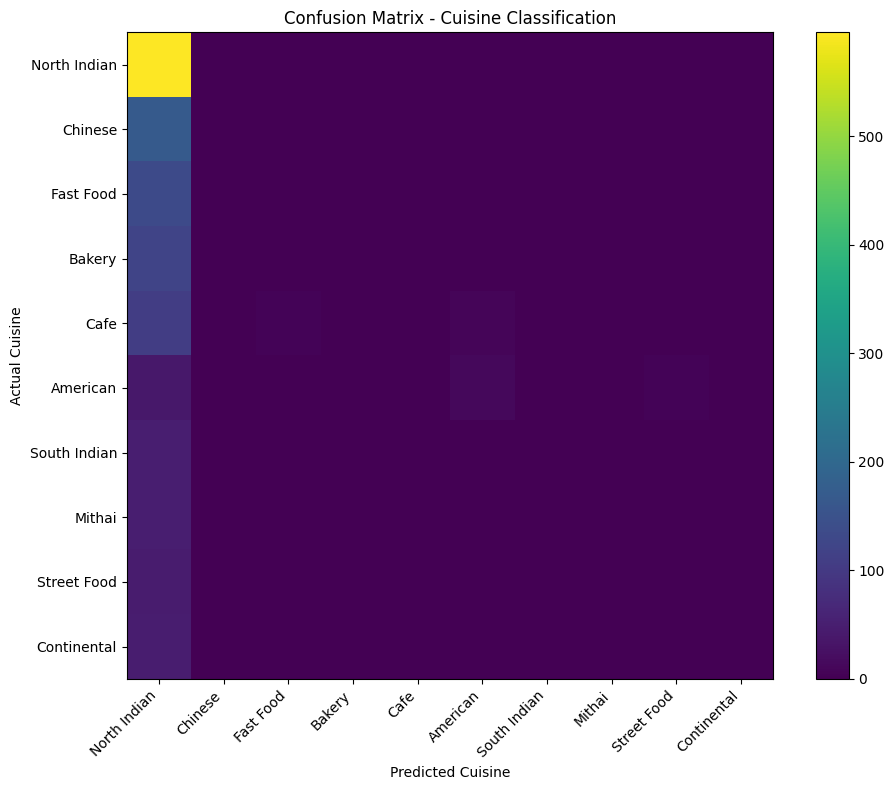

In [19]:
cm = confusion_matrix(y_test, y_pred, labels=top_cuisines)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.xticks(range(len(top_cuisines)), top_cuisines, rotation=45, ha="right")
plt.yticks(range(len(top_cuisines)), top_cuisines)
plt.xlabel("Predicted Cuisine")
plt.ylabel("Actual Cuisine")
plt.title("Confusion Matrix - Cuisine Classification")
plt.colorbar()
plt.tight_layout()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [21]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average="weighted", zero_division=0)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))

Random Forest Performance
-------------------------
Accuracy : 0.412
Precision: 0.366
Recall   : 0.412


In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.434783,0.298312,0.434783
1,Random Forest,0.411974,0.366107,0.411974


In [23]:
print("Performance Analysis by Cuisine")
print("--------------------------------")

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

performance = pd.DataFrame(report).transpose()

performance = performance.loc[
    performance.index.intersection(top_cuisines),
    ["precision", "recall", "f1-score"]
]

performance.sort_values("f1-score", ascending=False)

Performance Analysis by Cuisine
--------------------------------


,precision,recall,f1-score
North Indian,0.437913,0.994992,0.608163
American,0.500000,0.214286,0.300000
Street Food,0.111111,0.021277,0.035714
Cafe,1.000000,0.008130,0.016129
Bakery,0.000000,0.000000,0.000000
Chinese,0.000000,0.000000,0.000000
Fast Food,0.000000,0.000000,0.000000
Continental,0.000000,0.000000,0.000000
Mithai,0.000000,0.000000,0.000000
South Indian,0.000000,0.000000,0.000000


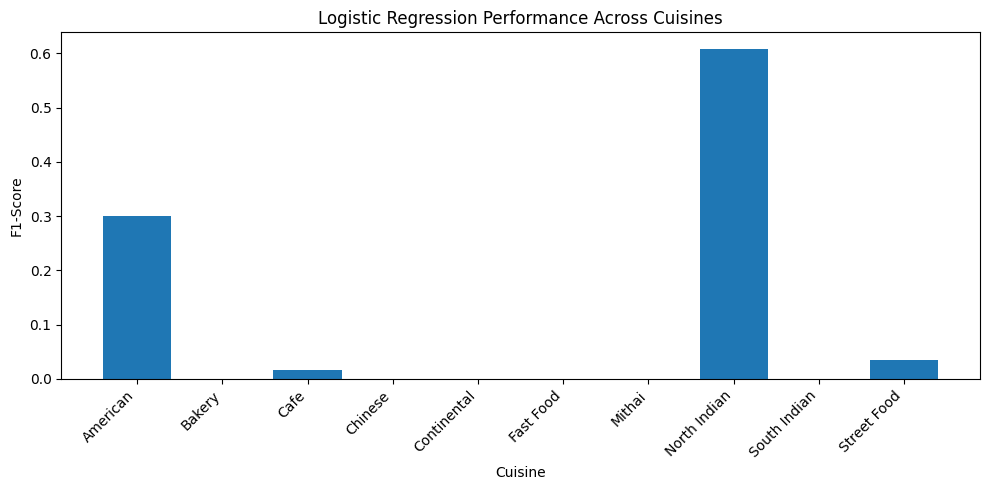

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    performance.index,
    performance["f1-score"]
)

plt.xlabel("Cuisine")
plt.ylabel("F1-Score")
plt.title("Logistic Regression Performance Across Cuisines")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Challenges and Potential Biases

- The dataset contains restaurants with multiple cuisines, so only the first listed cuisine was used as the primary cuisine.
- The classification was limited to the top 10 cuisines, which may introduce class imbalance.
- Some cuisines have fewer samples than others, making them harder to classify accurately.
- The available features may not contain enough information to clearly distinguish between similar cuisines.
- City, price range, ratings, and restaurant characteristics may influence the classification results.
- Excluding less frequent cuisines means the model may not generalize well to rare cuisines.

# Conclusion

The Cuisine Classification project was successfully developed using machine learning techniques.

Two classification models, Logistic Regression and Random Forest, were implemented and evaluated using accuracy, precision, and recall.

### Model Performance

- Logistic Regression achieved an accuracy of **43.5%**, precision of **29.8%**, and recall of **43.5%**.
- Random Forest achieved an accuracy of **41.2%**, precision of **36.6%**, and recall of **41.2%**.
- Logistic Regression achieved the higher overall accuracy and recall among the tested models.

Performance was also analyzed across individual cuisines using precision, recall, and F1-score.

### Key Findings

The results show that cuisine classification is challenging using the available restaurant features. Differences in the number of samples per cuisine, overlapping cuisine characteristics, and limited predictive features affected model performance.

Overall, the project demonstrates the application of preprocessing, categorical encoding, train-test splitting, classification algorithms, model evaluation, and performance analysis for restaurant cuisine classification.